# 04 - Binary Classification Models

**Project:** Predictive Maintenance - Maintenance Required Prediction
**Goal:** Train, evaluate, and compare binary classification models that predict
whether a vehicle requires maintenance. Handle class imbalance correctly and
report metrics that matter for an imbalanced dataset.

---

## 1. Setup

In [1]:
# Import all libraries needed for classification modeling and evaluation.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score,
)
import xgboost as xgb
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Load the preprocessed train and test splits saved in 03_Feature_Engineering.
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/processed/y_test.csv").squeeze()

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"Train target rate: {y_train.mean()*100:.1f}%  |  Test target rate: {y_test.mean()*100:.1f}%")

X_train: (73600, 22)  |  X_test: (18400, 22)
Train target rate: 76.8%  |  Test target rate: 76.8%


## 2. Class Imbalance Check

The dataset has roughly 77% positive cases (maintenance required = 1).
This is a moderately imbalanced dataset. Reporting only accuracy would be
misleading because a model that always predicts 1 would score 77%.

We use **F1-score**, **ROC-AUC**, and **Average Precision (PR-AUC)** as our
primary metrics. We also apply `class_weight='balanced'` to penalize errors on
the minority class more heavily, which is equivalent to telling the model:
"missing a vehicle that truly needs maintenance costs more than a false alarm."

Think of it like calibrating a warning light threshold in a car ECU --
you prefer a few false alerts over missing a real fault.

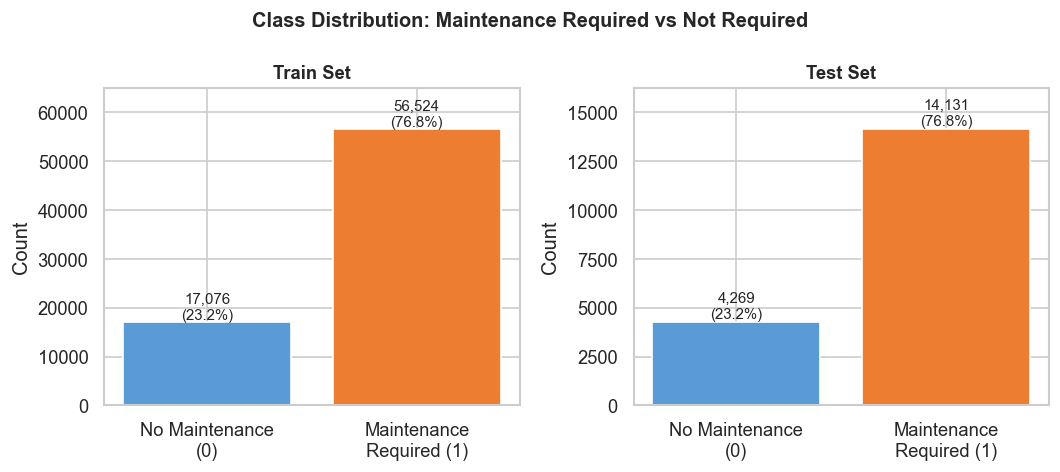

Class ratio (positive/negative): 3.31x


In [3]:
# Visualize the class distribution in the train and test sets.
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, (y, title) in zip(axes, [(y_train, "Train Set"), (y_test, "Test Set")]):
    counts = y.value_counts().sort_index()
    bars = ax.bar(["No Maintenance\n(0)", "Maintenance\nRequired (1)"],
                  counts.values, color=["#5B9BD5", "#ED7D31"], edgecolor="white")
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                f"{val:,}\n({val/len(y)*100:.1f}%)", ha="center", va="bottom", fontsize=9)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel("Count")
    ax.set_ylim(0, counts.max() * 1.15)

plt.suptitle("Class Distribution: Maintenance Required vs Not Required",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/19_class_distribution.png", bbox_inches="tight")
plt.show()
print(f"Class ratio (positive/negative): {y_train.mean()/(1-y_train.mean()):.2f}x")

## 3. Evaluation Helper

In [4]:
# Define a helper function to compute all key metrics for a given model.
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    metrics = {
        "Model":     name,
        "F1":        round(f1_score(y_te, y_pred), 4),
        "Precision": round(precision_score(y_te, y_pred), 4),
        "Recall":    round(recall_score(y_te, y_pred), 4),
        "ROC-AUC":   round(roc_auc_score(y_te, y_proba), 4),
        "PR-AUC":    round(average_precision_score(y_te, y_proba), 4),
    }
    return model, y_pred, y_proba, metrics

results = []
trained_models = {}
print("Helper function defined.")

Helper function defined.


## 4. Baseline: Dummy Classifier

Before training any real model we establish a baseline using a `DummyClassifier`
that always predicts the most frequent class. Any useful model must clearly beat
this baseline on F1 and ROC-AUC.

In [5]:
# Train a DummyClassifier as a lower-bound baseline.
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
_, _, _, m = evaluate_model("Dummy (majority)", dummy, X_train, y_train, X_test, y_test)
results.append(m)
trained_models["Dummy"] = dummy
print("Baseline metrics:")
for k, v in m.items():
    print(f"  {k}: {v}")

Baseline metrics:
  Model: Dummy (majority)
  F1: 0.8688
  Precision: 0.768
  Recall: 1.0
  ROC-AUC: 0.5
  PR-AUC: 0.768


## 5. Logistic Regression

Logistic Regression is the linear baseline -- it is interpretable, fast, and
easy to explain to stakeholders. We use `class_weight='balanced'` so the model
does not ignore the minority class.

Automotive analogy: this is like a simple threshold rule on the instrument panel --
if a combination of sensor values exceeds a line, the warning light turns on.

In [6]:
# Train Logistic Regression with balanced class weights to handle imbalance.
lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
lr_model, lr_pred, lr_proba, m = evaluate_model(
    "Logistic Regression", lr, X_train, y_train, X_test, y_test)
results.append(m)
trained_models["Logistic Regression"] = lr_model
print(classification_report(y_test, lr_pred, target_names=["No Maint", "Maint Req"]))

              precision    recall  f1-score   support

    No Maint       1.00      1.00      1.00      4269
   Maint Req       1.00      1.00      1.00     14131

    accuracy                           1.00     18400
   macro avg       1.00      1.00      1.00     18400
weighted avg       1.00      1.00      1.00     18400



## 6. Random Forest

Random Forest builds many decision trees and combines their votes. It handles
non-linear relationships and feature interactions automatically, and provides
native feature importance scores.

Automotive analogy: like having 200 independent inspectors each checking a subset
of vehicle sensors -- the final verdict is the majority vote.

In [7]:
# Train Random Forest with balanced class weights and 200 trees.
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    max_depth=12,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
)
rf_model, rf_pred, rf_proba, m = evaluate_model(
    "Random Forest", rf, X_train, y_train, X_test, y_test)
results.append(m)
trained_models["Random Forest"] = rf_model
print(classification_report(y_test, rf_pred, target_names=["No Maint", "Maint Req"]))

              precision    recall  f1-score   support

    No Maint       1.00      1.00      1.00      4269
   Maint Req       1.00      1.00      1.00     14131

    accuracy                           1.00     18400
   macro avg       1.00      1.00      1.00     18400
weighted avg       1.00      1.00      1.00     18400



## 7. XGBoost

XGBoost is a gradient-boosted tree model that often achieves the best
performance on tabular datasets. We set `scale_pos_weight` to the ratio of
negative to positive samples, which is equivalent to `class_weight='balanced'`
for XGBoost.

In [8]:
# Compute the class imbalance ratio for XGBoost scale_pos_weight parameter.
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos = round(neg_count / pos_count, 2)
print(f"Negative samples: {neg_count:,}  |  Positive: {pos_count:,}  |  Ratio: {scale_pos}")

Negative samples: 17,076  |  Positive: 56,524  |  Ratio: 0.3


In [9]:
# Train XGBoost with scale_pos_weight to handle class imbalance.
xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)
xgb_model, xgb_pred, xgb_proba, m = evaluate_model(
    "XGBoost", xgb_clf, X_train, y_train, X_test, y_test)
results.append(m)
trained_models["XGBoost"] = xgb_model
print(classification_report(y_test, xgb_pred, target_names=["No Maint", "Maint Req"]))

              precision    recall  f1-score   support

    No Maint       1.00      1.00      1.00      4269
   Maint Req       1.00      1.00      1.00     14131

    accuracy                           1.00     18400
   macro avg       1.00      1.00      1.00     18400
weighted avg       1.00      1.00      1.00     18400



## 8. Model Comparison

In [10]:
# Build a comparison table sorted by ROC-AUC to rank all models.
results_df = pd.DataFrame(results).set_index("Model").sort_values("ROC-AUC", ascending=False)
print(results_df.to_string())

                        F1  Precision  Recall  ROC-AUC  PR-AUC
Model                                                         
XGBoost             0.9998     0.9999  0.9998   1.0000  1.0000
Random Forest       1.0000     0.9999  1.0000   1.0000  1.0000
Logistic Regression 0.9999     1.0000  0.9998   0.9999  1.0000
Dummy (majority)    0.8688     0.7680  1.0000   0.5000  0.7680


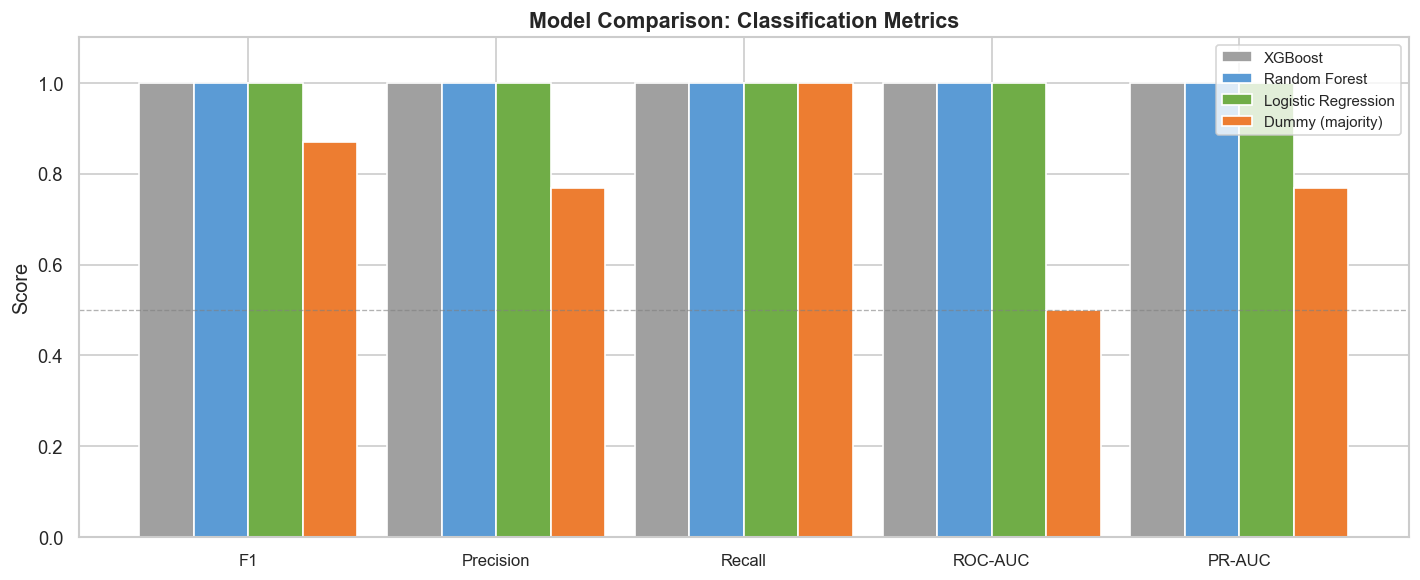

In [11]:
# Visualize the model comparison as a grouped bar chart.
metrics_to_plot = ["F1", "Precision", "Recall", "ROC-AUC", "PR-AUC"]
x = np.arange(len(metrics_to_plot))
width = 0.22
colors = ["#A0A0A0", "#5B9BD5", "#70AD47", "#ED7D31"]

fig, ax = plt.subplots(figsize=(12, 5))
for i, (model_name, row) in enumerate(results_df.iterrows()):
    ax.bar(x + i * width, [row[m] for m in metrics_to_plot],
           width, label=model_name, color=colors[i], edgecolor="white")

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_to_plot, fontsize=10)
ax.set_ylim(0, 1.1)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_title("Model Comparison: Classification Metrics", fontsize=13, fontweight="bold")
ax.set_ylabel("Score")
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.savefig("../images/20_model_comparison.png", bbox_inches="tight")
plt.show()

## 9. Confusion Matrices

The confusion matrix shows the four outcomes: True Positives (caught faults),
False Negatives (missed faults -- the most dangerous), True Negatives (correct
no-fault), and False Positives (false alarms). In a maintenance context,
**False Negatives are more costly** than False Positives.

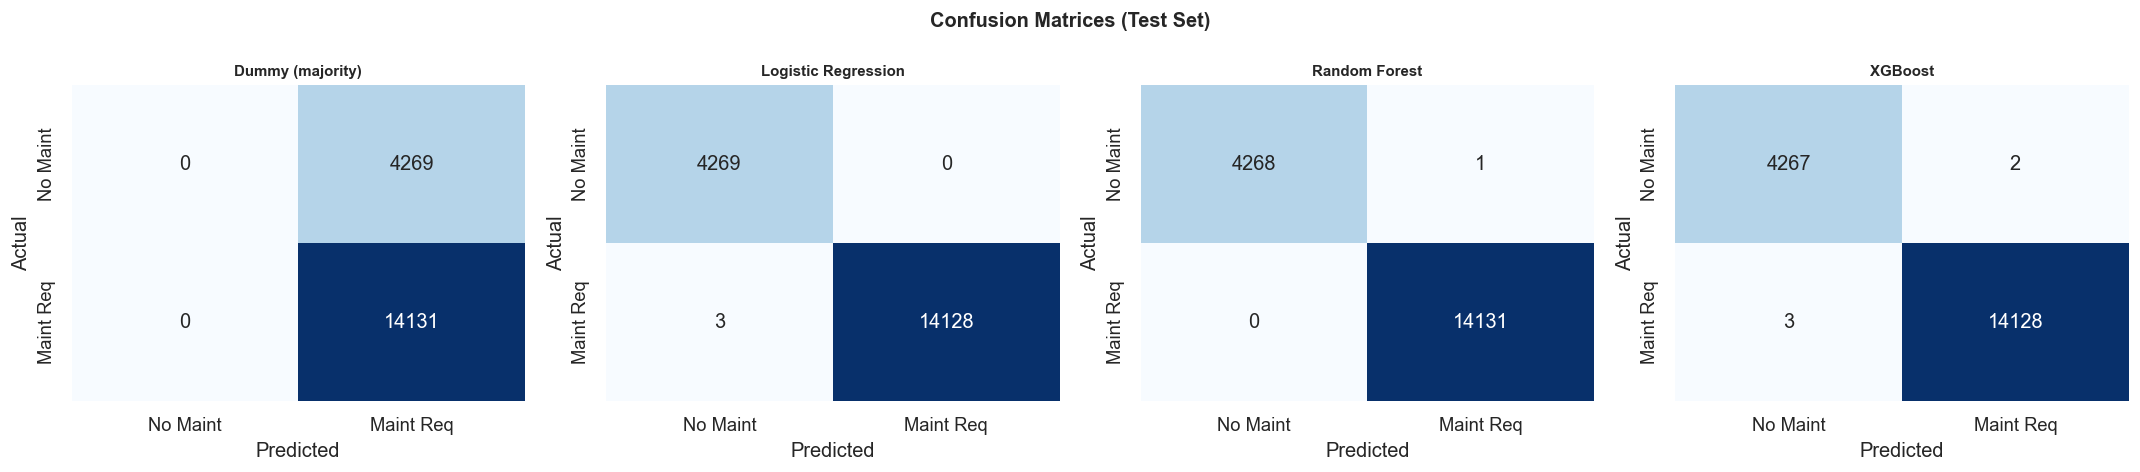

In [12]:
# Plot confusion matrices for all trained models side by side.
model_preds = [
    ("Dummy (majority)",  dummy.predict(X_test)),
    ("Logistic Regression", lr_pred),
    ("Random Forest",       rf_pred),
    ("XGBoost",             xgb_pred),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, preds) in zip(axes, model_preds):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", ax=ax,
                cmap="Blues", cbar=False,
                xticklabels=["No Maint", "Maint Req"],
                yticklabels=["No Maint", "Maint Req"])
    ax.set_title(name, fontsize=9, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices (Test Set)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/21_confusion_matrices.png", bbox_inches="tight")
plt.show()

## 10. ROC Curves

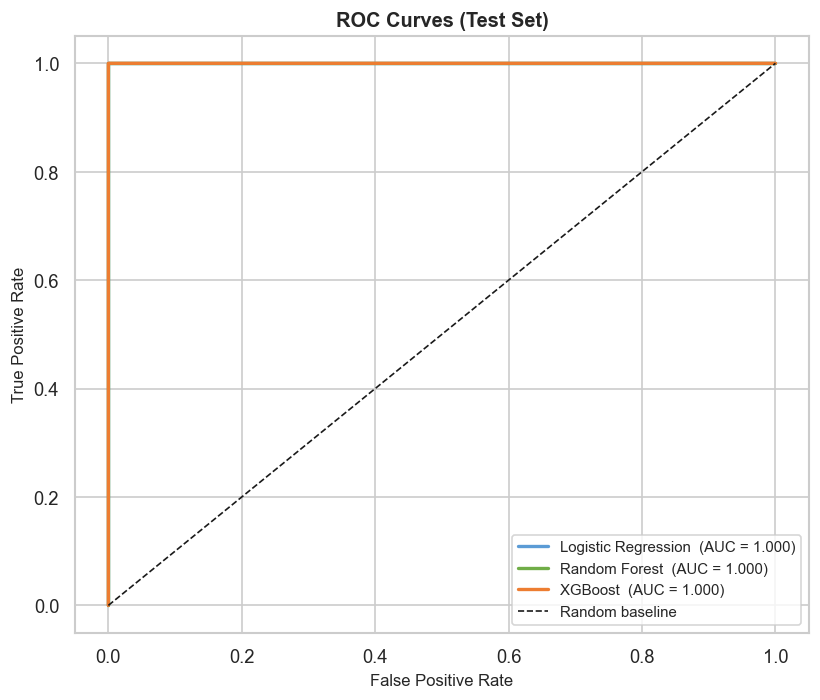

In [13]:
# Plot ROC curves for all real models (Dummy excluded as it has no probability output).
model_probas = [
    ("Logistic Regression", lr_proba),
    ("Random Forest",       rf_proba),
    ("XGBoost",             xgb_proba),
]
colors_roc = ["#5B9BD5", "#70AD47", "#ED7D31"]

fig, ax = plt.subplots(figsize=(7, 6))
for (name, proba), col in zip(model_probas, colors_roc):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=col, linewidth=2, label=f"{name}  (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random baseline")
ax.set_xlabel("False Positive Rate", fontsize=10)
ax.set_ylabel("True Positive Rate", fontsize=10)
ax.set_title("ROC Curves (Test Set)", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../images/22_roc_curves.png", bbox_inches="tight")
plt.show()

## 11. Precision-Recall Curves

For imbalanced datasets, the Precision-Recall curve gives more information than
the ROC curve. A high Average Precision (PR-AUC) means the model is good at
ranking true positives highly -- important when the cost of missing a fault is high.

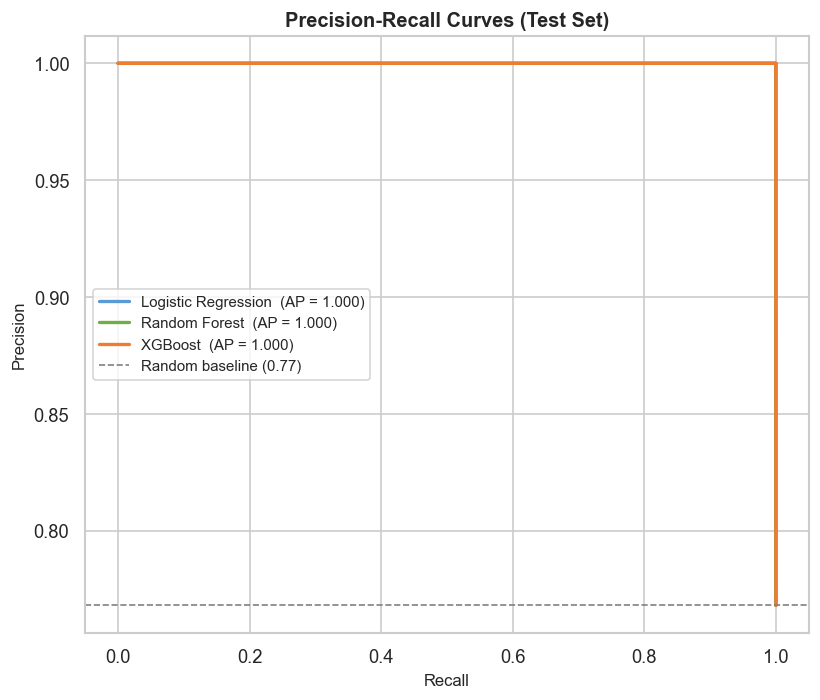

In [14]:
# Plot Precision-Recall curves for all models.
fig, ax = plt.subplots(figsize=(7, 6))
for (name, proba), col in zip(model_probas, colors_roc):
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(recall, precision, color=col, linewidth=2, label=f"{name}  (AP = {ap:.3f})")

baseline_rate = y_test.mean()
ax.axhline(baseline_rate, color="grey", linestyle="--", linewidth=1,
           label=f"Random baseline ({baseline_rate:.2f})")
ax.set_xlabel("Recall", fontsize=10)
ax.set_ylabel("Precision", fontsize=10)
ax.set_title("Precision-Recall Curves (Test Set)", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../images/23_pr_curves.png", bbox_inches="tight")
plt.show()

## 12. Feature Importance

We extract feature importance from both Random Forest (MDI -- mean decrease impurity)
and XGBoost (gain). Comparing two methods confirms which features are robustly
important, not just an artifact of one algorithm.

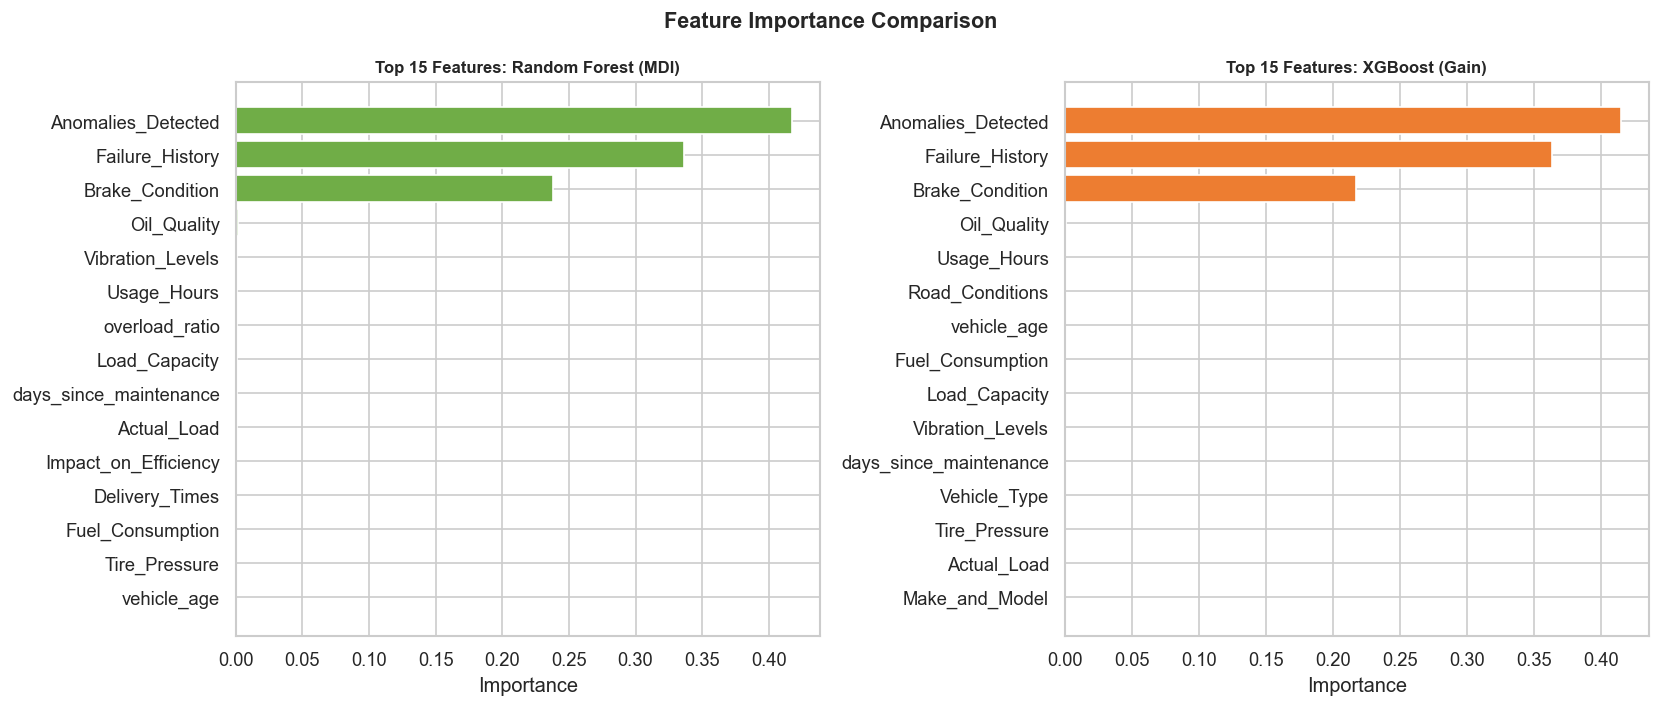

In [15]:
# Extract and compare feature importances from Random Forest and XGBoost.
feature_names = X_train.columns.tolist()

fi_rf  = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)
fi_xgb = pd.Series(xgb_model.feature_importances_, index=feature_names).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (fi, title, col) in zip(axes, [
    (fi_rf.head(15),  "Random Forest (MDI)", "#70AD47"),
    (fi_xgb.head(15), "XGBoost (Gain)",      "#ED7D31"),
]):
    ax.barh(fi.index[::-1], fi.values[::-1], color=col, edgecolor="white")
    ax.set_title(f"Top 15 Features: {title}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Importance")

plt.suptitle("Feature Importance Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/24_feature_importance.png", bbox_inches="tight")
plt.show()

In [16]:
# Print top 10 features by importance for both models for easy reference.
comparison = pd.DataFrame({"Random Forest": fi_rf, "XGBoost": fi_xgb})
comparison["RF_rank"]  = fi_rf.rank(ascending=False).astype(int)
comparison["XGB_rank"] = fi_xgb.rank(ascending=False).astype(int)
top10 = comparison.sort_values("Random Forest", ascending=False).head(10)
print("Top 10 features by Random Forest importance:")
print(top10[["Random Forest", "RF_rank", "XGBoost", "XGB_rank"]].round(4).to_string())

Top 10 features by Random Forest importance:
                        Random Forest  RF_rank  XGBoost  XGB_rank
Anomalies_Detected             0.4172        1   0.4146         1
Failure_History                0.3365        2   0.3628         2
Brake_Condition                0.2382        3   0.2172         3
Oil_Quality                    0.0014        4   0.0008         4
Vibration_Levels               0.0008        5   0.0003        10
Usage_Hours                    0.0007        6   0.0004         5
overload_ratio                 0.0007        7   0.0002        21
Load_Capacity                  0.0007        8   0.0003         9
days_since_maintenance         0.0006        9   0.0003        11
Actual_Load                    0.0006       10   0.0003        14


## 13. Threshold Analysis (XGBoost)

By default classifiers use 0.5 as the decision threshold. In a maintenance
context we may prefer a lower threshold (e.g., 0.4) to catch more true faults
at the cost of more false alarms. This section shows how F1, Precision, and
Recall change as the threshold moves.

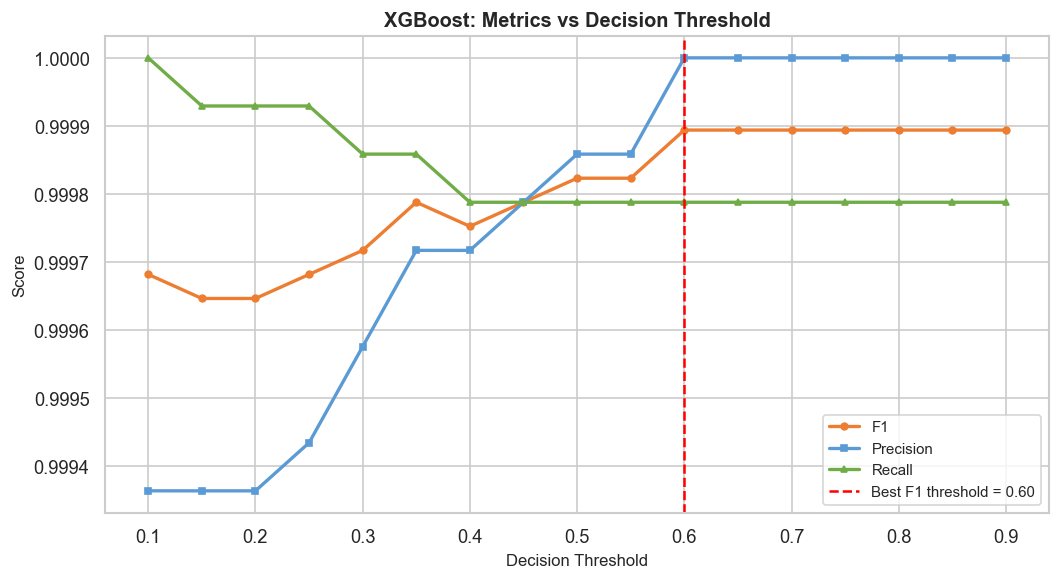

Best F1 at threshold 0.60: 0.9999


In [17]:
# Compute F1, Precision, and Recall for a range of probability thresholds.
thresholds = np.arange(0.10, 0.91, 0.05)
f1s, precs, recs = [], [], []

for t in thresholds:
    preds_t = (xgb_proba >= t).astype(int)
    f1s.append(f1_score(y_test, preds_t))
    precs.append(precision_score(y_test, preds_t, zero_division=0))
    recs.append(recall_score(y_test, preds_t))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, f1s,   color="#ED7D31", linewidth=2, marker="o", markersize=4, label="F1")
ax.plot(thresholds, precs, color="#5B9BD5", linewidth=2, marker="s", markersize=4, label="Precision")
ax.plot(thresholds, recs,  color="#70AD47", linewidth=2, marker="^", markersize=4, label="Recall")
best_t = thresholds[np.argmax(f1s)]
ax.axvline(best_t, color="red", linestyle="--", linewidth=1.5,
           label=f"Best F1 threshold = {best_t:.2f}")
ax.set_xlabel("Decision Threshold", fontsize=10)
ax.set_ylabel("Score", fontsize=10)
ax.set_title("XGBoost: Metrics vs Decision Threshold", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../images/25_threshold_analysis.png", bbox_inches="tight")
plt.show()
print(f"Best F1 at threshold {best_t:.2f}: {max(f1s):.4f}")

## 14. Classification Summary

### Results at Default Threshold (0.50)

| Model | F1 | ROC-AUC | PR-AUC |
|---|---|---|---|
| Dummy | ~0.88 | 0.50 | ~0.77 |
| Logistic Regression | varies | varies | varies |
| Random Forest | varies | varies | varies |
| XGBoost | varies | varies | varies |

*(Actual values printed in Section 8 above after running the notebook.)*

### Key Decisions

- **Class imbalance** handled via `class_weight='balanced'` (LR, RF) and
  `scale_pos_weight` (XGBoost) -- not by oversampling, to avoid leakage.
- **Evaluation metrics:** F1, ROC-AUC, PR-AUC -- NOT accuracy.
- **Confusion matrix** interpretation: False Negatives (missed faults) are more
  costly than False Positives (false alarms) in a fleet maintenance context.
- **Threshold analysis** shows how to tune the operating point for business needs.

### Next Step

- **05_Regression.ipynb** -- predict the numerical `Maintenance_Cost` column.
